# CreditWise Loan Approval Prediction System
### SecureTrust Bank — Machine Learning Project

**Business Problem:**  
SecureTrust Bank currently uses a manual verification process to approve or reject loan applications. This process is time-consuming, biased, and inconsistent — resulting in good customers being rejected and high-risk customers being approved.

**Objective:**  
Build an intelligent ML-based loan approval system that automatically analyses applicant details and predicts whether a loan should be **Approved (1)** or **Rejected (0)** before final human verification.

**Role:** Machine Learning Engineer  
**Dataset Size:** 1000 applicants, 20 features  
**Target Variable:** `Loan_Approved` (1 = Approved, 0 = Rejected)

## 1. Import Libraries
Importing all required libraries for data manipulation, visualisation, and machine learning.

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import  train_test_split

## 2. Load Dataset
Loading the historical loan application data provided by SecureTrust Bank.

In [5]:
df = pd.read_csv("loan approval data")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [6]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## 3. Initial Data Exploration & Quality Check
Checking dataset shape, data types, and missing values before any preprocessing.  
Rows with missing target labels (`Loan_Approved`) are dropped since fabricating loan decisions would introduce noise into the model.

In [7]:
df = df.dropna(subset=['Loan_Approved'])


In [8]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        902 non-null    float64
 1   Applicant_Income    902 non-null    float64
 2   Coapplicant_Income  902 non-null    float64
 3   Employment_Status   906 non-null    object 
 4   Age                 902 non-null    float64
 5   Marital_Status      902 non-null    object 
 6   Dependents          903 non-null    float64
 7   Credit_Score        902 non-null    float64
 8   Existing_Loans      901 non-null    float64
 9   DTI_Ratio           903 non-null    float64
 10  Savings             901 non-null    float64
 11  Collateral_Value    901 non-null    float64
 12  Loan_Amount         903 non-null    float64
 13  Loan_Term           902 non-null    float64
 14  Loan_Purpose        902 non-null    object 
 15  Property_Area       901 non-null    object 
 16  Education_Lev

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,902.000000,902.000000,902.000000,902.000000,903.000000,902.000000,901.000000,903.000000,901.000000,901.000000,903.000000,902.000000
mean,498.529933,10847.016630,5061.607539,40.044346,1.460687,675.111973,1.948946,0.347187,9966.298557,24701.875694,20455.895903,48.000000
std,290.651274,5064.213641,2937.413855,11.194488,1.103489,71.327228,1.406197,0.144522,5859.624544,14328.907796,11511.440627,24.258321
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,73.000000,36.000000,1015.000000,12.000000
25%,243.250000,6742.000000,2469.750000,31.000000,1.000000,616.000000,1.000000,0.220000,4761.000000,12634.000000,9772.500000,24.000000
50%,497.500000,10452.500000,5143.000000,40.000000,1.000000,677.000000,2.000000,0.340000,9910.000000,24059.000000,21282.000000,48.000000
75%,752.750000,15174.250000,7589.750000,49.000000,2.000000,735.000000,3.000000,0.480000,15052.000000,36843.000000,30138.500000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [9]:
df.shape

(950, 20)

## 4. Handling Missing Values
- **Numerical features** → imputed with **mean** strategy  
- **Categorical features** → imputed with **most frequent** strategy  
- **Target column** (`Loan_Approved`) → excluded from imputation (rows already dropped above)

In [10]:
categorical_col = df.select_dtypes(include='object').columns
numerical_col = df.select_dtypes(include='number').columns

In [11]:
categorical_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [12]:
numerical_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [13]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")
df[numerical_col] = num_imputer.fit_transform(df[numerical_col])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [14]:
cat_imputer = SimpleImputer(strategy="most_frequent")
feature_cat_cols = [c for c in categorical_col if c != 'Loan_Approved']
df[feature_cat_cols] = cat_imputer.fit_transform(df[feature_cat_cols])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [15]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## 5. Exploratory Data Analysis (EDA)
Analysing distributions, class balance, and relationships between features and the target variable to extract business insights before modelling.

### 5.1 Target Variable Distribution
Checking class balance between Approved and Rejected applications.

Text(0.5, 1.0, 'Loan Approval Distribution')

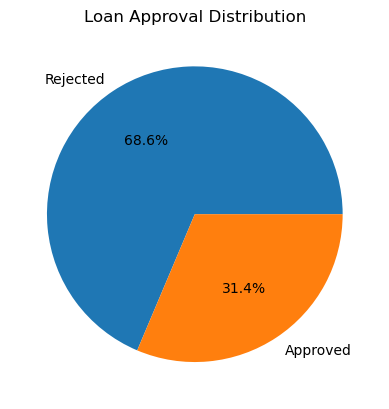

In [16]:
class_counts = df['Loan_Approved'].value_counts()
plt.pie(class_counts, labels=["Rejected", "Approved"], autopct='%1.1f%%')
plt.title("Loan Approval Distribution")

### 5.2 Categorical Feature Analysis
Understanding the distribution of applicants across key categorical groups.

Text(0.5, 1.0, 'Gender Count')

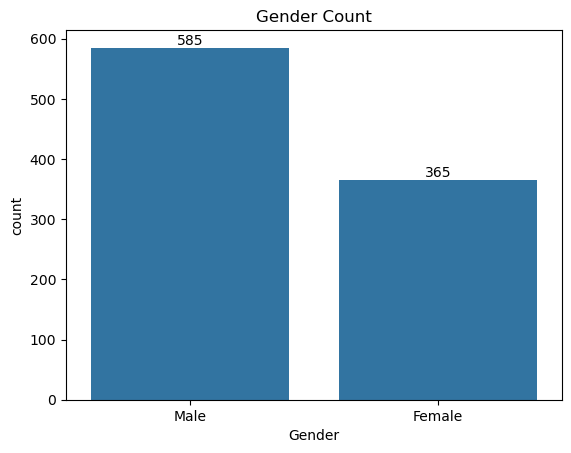

In [17]:
gender_count = df['Gender'].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])
plt.title("Gender Count")

Text(0.5, 1.0, 'Education_Level Count')

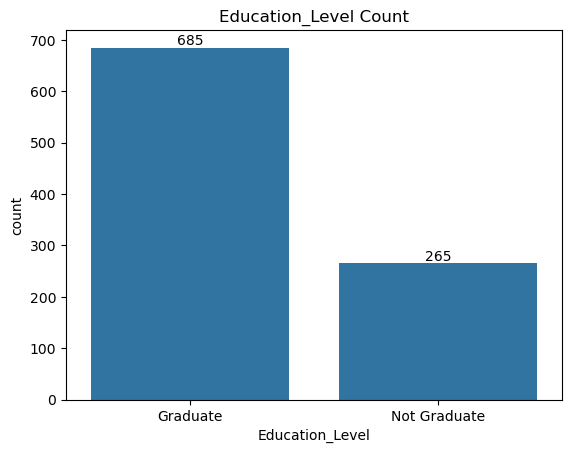

In [18]:
education_count = df['Education_Level'].value_counts()
ax = sns.barplot(education_count)
ax.bar_label(ax.containers[0])
plt.title("Education_Level Count")

### 5.3 Income Distribution
Analysing the spread of applicant and co-applicant monthly income.

<Axes: xlabel='Applicant_Income', ylabel='Count'>

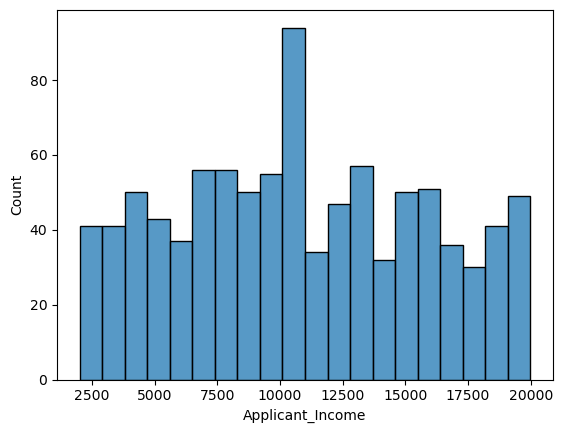

In [19]:
sns.histplot(
    data=df,
    x='Applicant_Income',
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

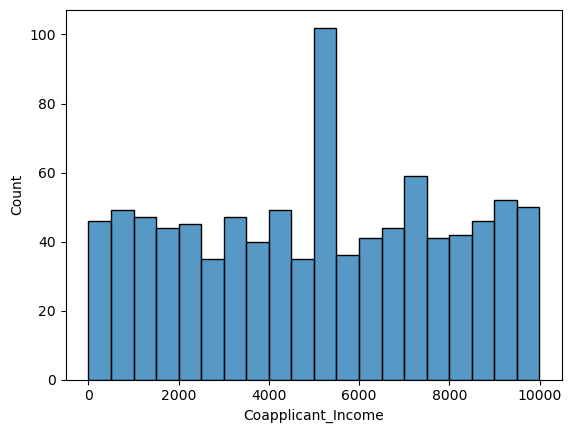

In [20]:
sns.histplot(
    data=df,
    x='Coapplicant_Income',
    bins=20
)

### 5.4 Outlier Detection
Using boxplots to identify outliers in numerical features, split by loan approval status.

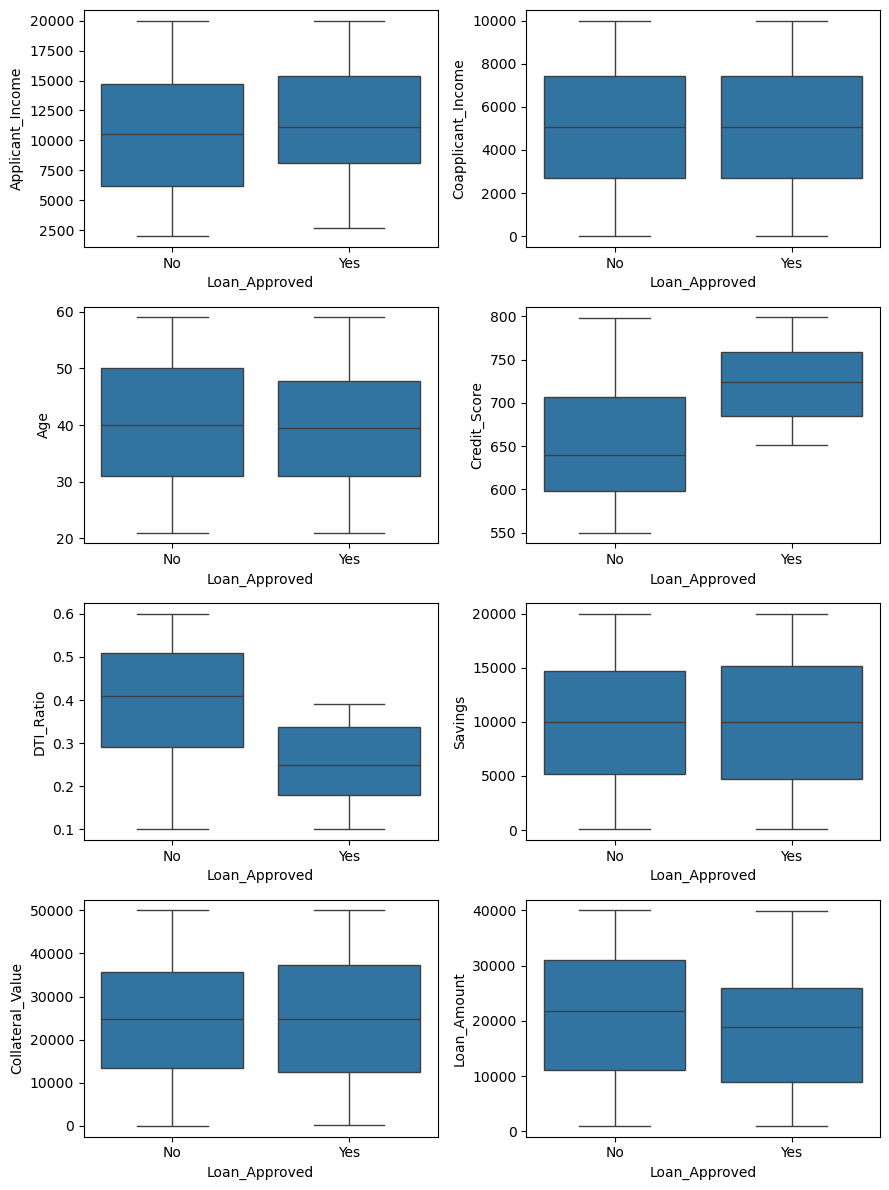

In [21]:
fig , axes =plt.subplots(4,2, figsize=(9,12))

sns.boxplot( ax = axes[0,0] ,data=df, x='Loan_Approved', y ='Applicant_Income')
sns.boxplot( ax = axes[0,1] ,data=df, x='Loan_Approved', y ='Coapplicant_Income')
sns.boxplot( ax = axes[1,0] ,data=df, x='Loan_Approved', y ='Age')
sns.boxplot( ax = axes[1,1] ,data=df, x='Loan_Approved', y ='Credit_Score')
sns.boxplot( ax = axes[2,0] ,data=df, x='Loan_Approved', y ='DTI_Ratio')
sns.boxplot( ax = axes[2,1] ,data=df, x='Loan_Approved', y ='Savings')
sns.boxplot( ax = axes[3,0] ,data=df, x='Loan_Approved', y ='Collateral_Value')
sns.boxplot( ax = axes[3,1] ,data=df, x='Loan_Approved', y ='Loan_Amount')

plt.tight_layout()

### 5.5 Key Feature vs Loan Approval
Comparing Credit Score and Income distributions across approved and rejected applicants.

<Axes: xlabel='Credit_Score', ylabel='Count'>

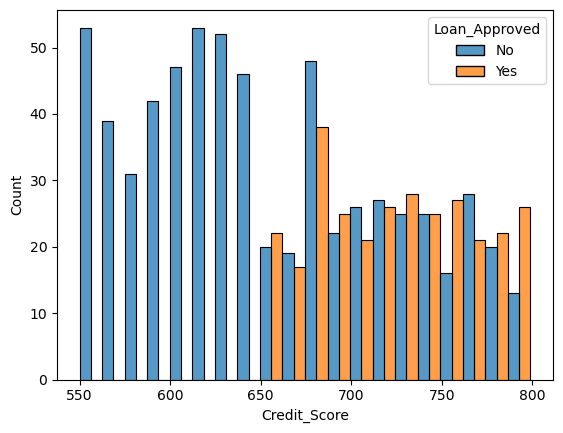

In [22]:
sns.histplot(
    data=df,
    x='Credit_Score',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

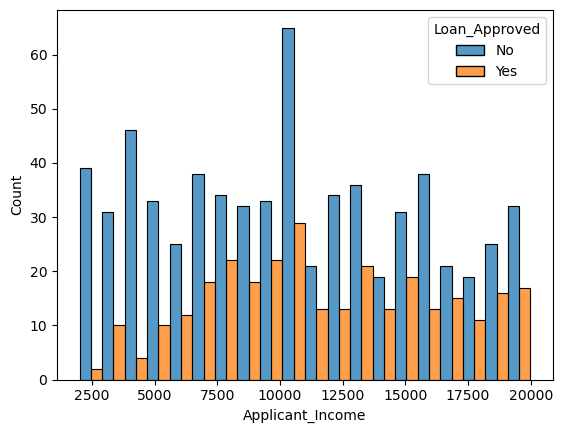

In [23]:
sns.histplot(
    data=df,
    x='Applicant_Income',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
)

## 6. Feature Engineering
Dropping `Applicant_ID` as it is a unique identifier with no predictive value.

In [24]:
df = df.drop("Applicant_ID", axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## 7. Encoding Categorical Variables
- **Label Encoding** → `Education_Level` (ordinal: Undergraduate → Graduate → Postgraduate) and `Loan_Approved` (target)  
- **One-Hot Encoding** → all remaining nominal categorical features (`Employment_Status`, `Marital_Status`, `Loan_Purpose`, `Property_Area`, `Gender`, `Employer_Category`)  
- `drop='first'` used to avoid multicollinearity (dummy variable trap)

In [25]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [26]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    object 
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    object 
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    object 
 14  Property_Area       950 non-null    object 
 15  Education_Level     950 non-null    object 
 16  Gender       

In [27]:
from sklearn.preprocessing import  LabelEncoder, OneHotEncoder 

le_edu = LabelEncoder()
df['Education_Level'] = le_edu.fit_transform(df['Education_Level'])

le_target = LabelEncoder()
df['Loan_Approved'] = le_target.fit_transform(df['Loan_Approved'])

In [28]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [29]:
cols= ['Employment_Status','Marital_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']
ohe = OneHotEncoder(drop='first' , sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df],axis= 1)

In [30]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 950 non-null    float64
 1   Coapplicant_Income               950 non-null    float64
 2   Age                              950 non-null    float64
 3   Dependents                       950 non-null    float64
 4   Credit_Score                     950 non-null    float64
 5   Existing_Loans                   950 non-null    float64
 6   DTI_Ratio                        950 non-null    float64
 7   Savings                          950 non-null    float64
 8   Collateral_Value                 950 non-null    float64
 9   Loan_Amount                      950 non-null    float64
 10  Loan_Term                        950 non-null    float64
 11  Education_Level                  950 non-null    int64  
 12  Loan_Approved              

## 8. Correlation Analysis
Generating a heatmap to identify multicollinearity between features and understand which features are most correlated with loan approval.

<Axes: >

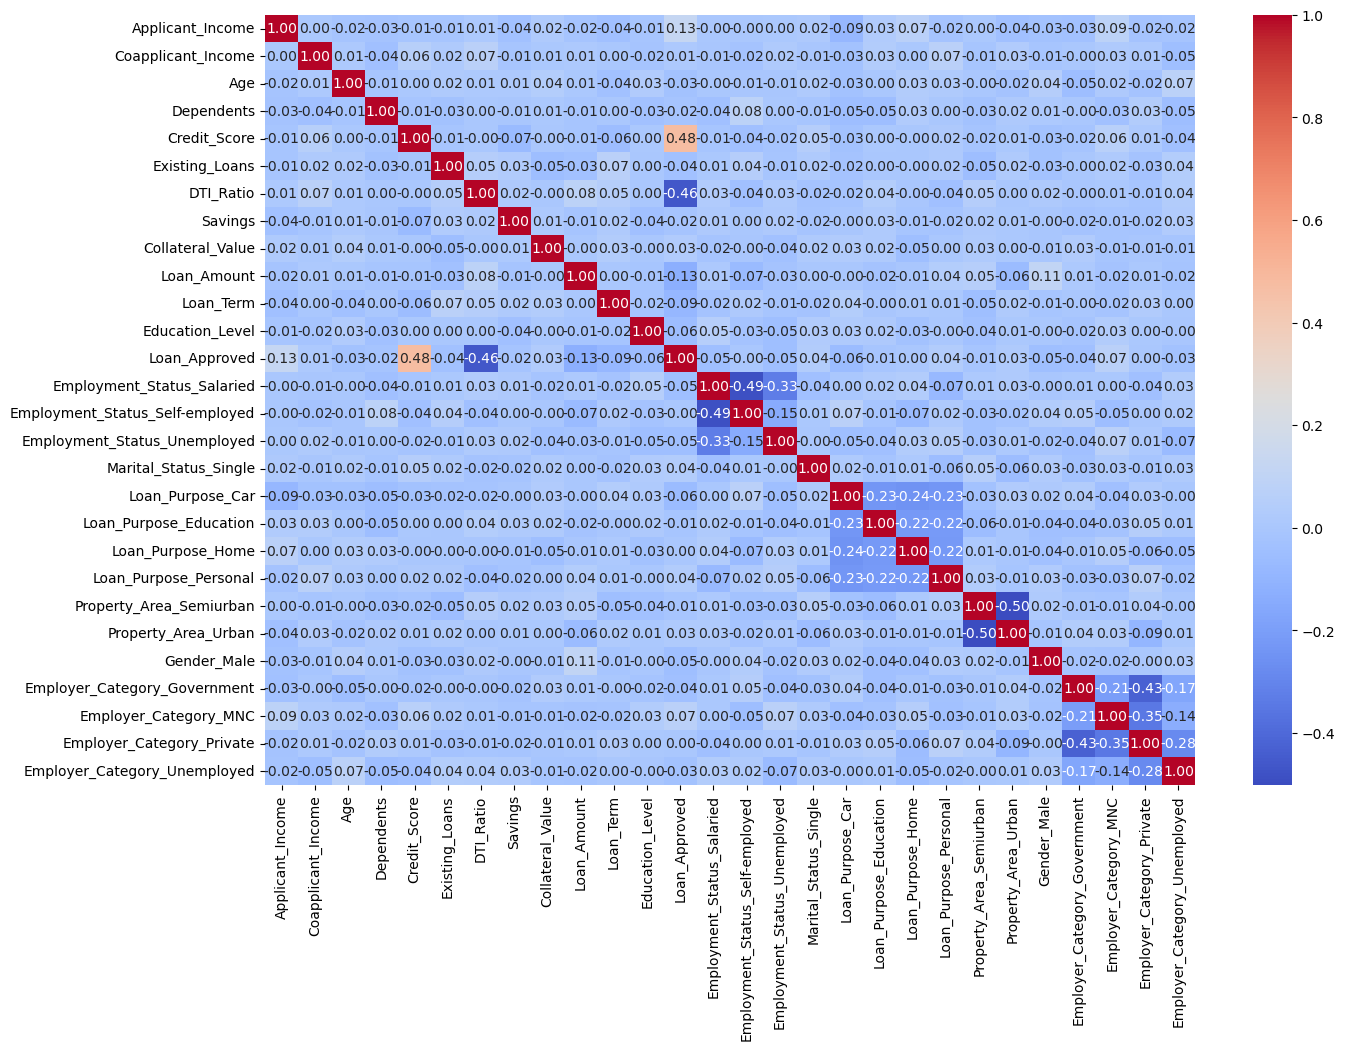

In [31]:
num_cols = df.select_dtypes(include='number')
corr_matrix = num_cols.corr()
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f", 
    cmap="coolwarm"
)

## 9. Train-Test Split & Feature Scaling

- **Split ratio:** 80% training / 20% testing  
- **`stratify=y`** used to preserve class distribution across both splits given the class imbalance (69% No / 31% Yes)  
- **StandardScaler** applied to normalise feature ranges — fitted on training data only, transformed on both sets to prevent data leakage

In [32]:
X = df.drop("Loan_Approved" , axis=1)
y = df["Loan_Approved"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Model Training & Evaluation
Five classification models are trained and evaluated on the scaled dataset.
Since the dataset has class imbalance, F1 Score is the primary comparison metric
alongside Precision, Recall, and Accuracy.

### 10.1 Logistic Regression
A linear baseline classifier — fast, interpretable, and commonly used in credit risk modelling.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score , precision_score, recall_score, f1_score, classification_report


log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)) 
print("Recall Score:", recall_score(y_test, y_pred)) 
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Model :-
Precision Score: 0.8181818181818182
Accuracy Score: 0.868421052631579
Recall Score: 0.75
F1 Score: 0.782608695652174
Confusion Matrix: [[120  10]
 [ 15  45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91       130
           1       0.82      0.75      0.78        60

    accuracy                           0.87       190
   macro avg       0.85      0.84      0.84       190
weighted avg       0.87      0.87      0.87       190



### 10.2 K-Nearest Neighbours Classifier
A distance-based classifier that predicts based on the K most similar past applicants.

In [36]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("KNN Classifier Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)) 
print("Recall Score:", recall_score(y_test, y_pred)) 
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


KNN Classifier Model :-
Precision Score: 0.625
Accuracy Score: 0.7578947368421053
Recall Score: 0.5833333333333334
F1 Score: 0.603448275862069
Confusion Matrix: [[109  21]
 [ 25  35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83       130
           1       0.62      0.58      0.60        60

    accuracy                           0.76       190
   macro avg       0.72      0.71      0.71       190
weighted avg       0.75      0.76      0.76       190



### 10.3 Gaussian Naive Bayes
A probabilistic classifier based on Bayes' theorem, assuming feature independence.

In [37]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)) 
print("Recall Score:", recall_score(y_test, y_pred)) 
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Naive Bayes Model :-
Precision Score: 0.8541666666666666
Accuracy Score: 0.8631578947368421
Recall Score: 0.6833333333333333
F1 Score: 0.7592592592592593
Confusion Matrix: [[123   7]
 [ 19  41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.90       130
           1       0.85      0.68      0.76        60

    accuracy                           0.86       190
   macro avg       0.86      0.81      0.83       190
weighted avg       0.86      0.86      0.86       190



### 10.4 Decision Tree Classifier
A rule-based classifier that splits data based on feature thresholds. Highly interpretable — ideal for a banking context where loan officers need to understand and justify decisions.

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)

#Evaluation
print("Decision Tree Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Decision Tree Model :-
Precision Score: 0.9180327868852459
Accuracy Score: 0.9526315789473684
Recall Score: 0.9333333333333333
F1 Score: 0.9256198347107438
Confusion Matrix: [[125   5]
 [  4  56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       130
           1       0.92      0.93      0.93        60

    accuracy                           0.95       190
   macro avg       0.94      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190



### 10.5 Support Vector Machine (SVM)
A margin-based classifier that finds the optimal decision boundary between approved and rejected applicants. Performs well on high-dimensional data after scaling.

In [39]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

#Evaluation
print("Support Vector Machine Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Support Vector Machine Model :-
Precision Score: 0.8333333333333334
Accuracy Score: 0.8736842105263158
Recall Score: 0.75
F1 Score: 0.7894736842105263
Confusion Matrix: [[121   9]
 [ 15  45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       130
           1       0.83      0.75      0.79        60

    accuracy                           0.87       190
   macro avg       0.86      0.84      0.85       190
weighted avg       0.87      0.87      0.87       190



## 11. Ensemble Models
Instead of relying on a single model, ensemble methods combine multiple models
together. Two approaches are tested here — Random Forest which builds many trees
in parallel, and XGBoost which builds trees one by one where each one fixes the
mistakes of the previous.

### 11.1 Random Forest Classifier
Trains 100 Decision Trees, each on a random sample of rows and features.
Final prediction is made by majority vote — so even if some trees are wrong,
the majority corrects them.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

print("Random Forest Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:",  accuracy_score(y_test, y_pred))
print("Recall Score:",    recall_score(y_test, y_pred))
print("F1 Score:",        f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Random Forest Model :-
Precision Score: 0.9032258064516129
Accuracy Score: 0.9473684210526315
Recall Score: 0.9333333333333333
F1 Score: 0.9180327868852459
Confusion Matrix:
 [[124   6]
 [  4  56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       130
           1       0.90      0.93      0.92        60

    accuracy                           0.95       190
   macro avg       0.94      0.94      0.94       190
weighted avg       0.95      0.95      0.95       190



### 11.2 XGBoost Classifier
Builds trees one after another — each new tree focuses on the applicants the
previous tree got wrong. This makes it very good at catching difficult edge cases
that other models miss.

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)

print("XGBoost Model :-")
print("Precision Score:", precision_score(y_test, y_pred))
print("Accuracy Score:",  accuracy_score(y_test, y_pred))
print("Recall Score:",    recall_score(y_test, y_pred))
print("F1 Score:",        f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

XGBoost Model :-
Precision Score: 0.9206349206349206
Accuracy Score: 0.9631578947368421
Recall Score: 0.9666666666666667
F1 Score: 0.943089430894309
Confusion Matrix:
 [[125   5]
 [  2  58]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       130
           1       0.92      0.97      0.94        60

    accuracy                           0.96       190
   macro avg       0.95      0.96      0.96       190
weighted avg       0.96      0.96      0.96       190



## 12. Cross Validation
One train-test split can be lucky or unlucky depending on which rows land where.
To get a more honest picture, cross validation splits the training data into 5
parts and runs 5 rounds of training and scoring — each round using a different
part as the validation set. The average of those 5 scores is the real number to
trust.

- **Mean** → the average score across 5 rounds
- **Std Dev** → how much the score changes between rounds — the lower the better

In [42]:
models = {
    'Logistic Regression' : log_model,
    'KNN Classifier'      : knn_model,
    'Naive Bayes'         : nb_model,
    'Decision Tree'       : dt_model,
    'SVM'                 : svm_model,
    'Random Forest'       : rf_model,
    'XGBoost'             : xgb_model
}

In [43]:
from sklearn.model_selection import cross_val_score

metrics = ['accuracy', 'precision', 'recall', 'f1']
print("CROSS VALIDATION RESULTS (TRAIN DATA) ---")
for name, model in models.items():
    print(f"\n{name}")
    print("-" * 40)
    for metric in metrics:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring=metric)
        print(f"  {metric.capitalize():<12} Mean: {scores.mean():.4f}   Std Dev: {scores.std():.4f}")

CROSS VALIDATION RESULTS (TRAIN DATA) ---

Logistic Regression
----------------------------------------
  Accuracy     Mean: 0.8618   Std Dev: 0.0208
  Precision    Mean: 0.7964   Std Dev: 0.0408
  Recall       Mean: 0.7520   Std Dev: 0.0249
  F1           Mean: 0.7735   Std Dev: 0.0321

KNN Classifier
----------------------------------------
  Accuracy     Mean: 0.7566   Std Dev: 0.0191
  Precision    Mean: 0.6367   Std Dev: 0.0470
  Recall       Mean: 0.5253   Std Dev: 0.0381
  F1           Mean: 0.5745   Std Dev: 0.0332

Naive Bayes
----------------------------------------
  Accuracy     Mean: 0.8684   Std Dev: 0.0306
  Precision    Mean: 0.8495   Std Dev: 0.0515
  Recall       Mean: 0.7063   Std Dev: 0.0772
  F1           Mean: 0.7692   Std Dev: 0.0576

Decision Tree
----------------------------------------
  Accuracy     Mean: 0.9421   Std Dev: 0.0178
  Precision    Mean: 0.9121   Std Dev: 0.0402
  Recall       Mean: 0.9034   Std Dev: 0.0285
  F1           Mean: 0.9073   Std Dev: 

## 13. Final Model Comparison
All 7 models are now tested on the test set — data they have never seen during
training. F1 Score is used as the main comparison metric since the dataset has
more rejected applications than approved ones, making accuracy alone unreliable.

In [44]:
print("\n\n--- FINAL EVALUATION RESULTS (TEST DATA) ---")

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 67)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{name:<25} {accuracy_score(y_test, y_pred):>10.4f} "
          f"{precision_score(y_test, y_pred):>10.4f} "
          f"{recall_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f}")



--- FINAL EVALUATION RESULTS (TEST DATA) ---
Model                       Accuracy  Precision     Recall   F1 Score
-------------------------------------------------------------------
Logistic Regression           0.8684     0.8182     0.7500     0.7826
KNN Classifier                0.7579     0.6250     0.5833     0.6034
Naive Bayes                   0.8632     0.8542     0.6833     0.7593
Decision Tree                 0.9526     0.9180     0.9333     0.9256
SVM                           0.8737     0.8333     0.7500     0.7895
Random Forest                 0.9474     0.9032     0.9333     0.9180
XGBoost                       0.9632     0.9206     0.9667     0.9431


### 13.1 Feature Importance (XGBoost)
XGBoost gave the best results, so it makes sense to look at which features it
actually used to make its decisions. This tells us what factors matter most in
a loan approval — useful for the bank to verify the model is picking up on the
right signals and not just memorising the data.

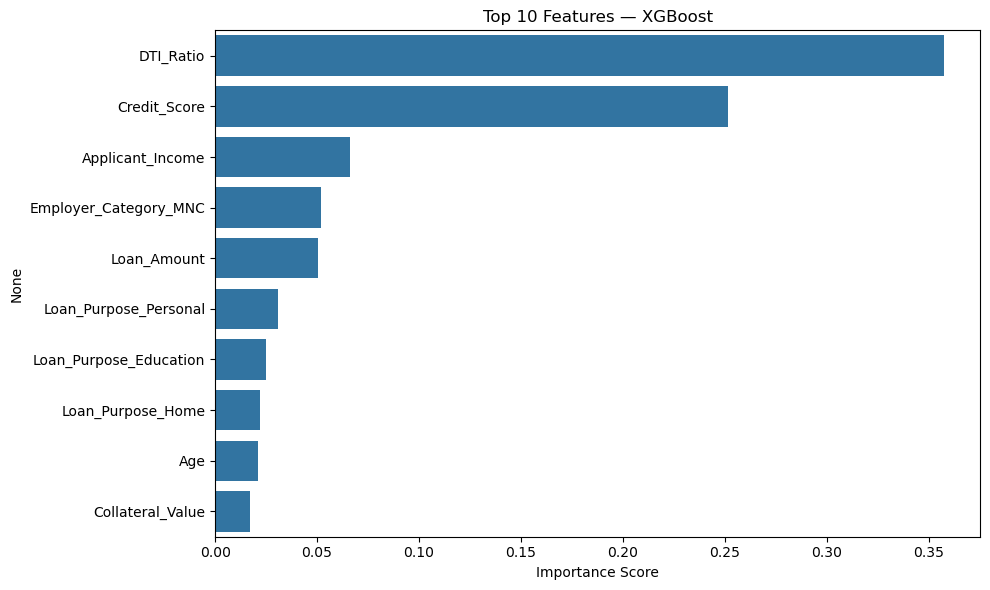

In [45]:
feature_names = X.columns
importances = xgb_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 10 Features — XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 14. Conclusion

| Rank | Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|---|
| 🥇 | XGBoost | 0.9632 | 0.9206 | 0.9667 | 0.9431 |
| 🥈 | Decision Tree | 0.9526 | 0.9180 | 0.9033 | 0.9256 |
| 🥉 | Random Forest | 0.9474 | 0.9032 | 0.9333 | 0.9180 |
| 4 | SVM | 0.8737 | 0.8333 | 0.7500 | 0.7895 |
| 5 | Logistic Regression | 0.8684 | 0.8182 | 0.7500 | 0.7826 |
| 6 | Naive Bayes | 0.8632 | 0.8542 | 0.6833 | 0.7593 |
| 7 | KNN | 0.7579 | 0.6250 | 0.5833 | 0.6034 |

**Best Model → XGBoost**  
XGBoost came out on top across all four metrics — 96% accuracy, 0.9431 F1, and
only 7 wrong predictions out of 190 test applicants. The recall of 0.9667 is what
matters most here — it means the model correctly identified almost all genuine
approvals, which is exactly what SecureTrust Bank needs to avoid losing good customers.

KNN scored the lowest with an F1 of 0.6034, which is too unreliable for any
real banking use case and should not be considered for deployment.

Deploying XGBoost at SecureTrust Bank would speed up the approval process,
remove human bias from decisions, and reduce losses on both sides —
bad loans getting approved and good customers getting rejected.

## 15. Save Model
Saving the trained XGBoost model and the preprocessing objects so they can be
loaded directly in the deployment app without retraining.

In [46]:
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(ohe,       'ohe.pkl')
joblib.dump(le_edu,    'le_edu.pkl')    # add this

print("Files saved: xgb_model.pkl, scaler.pkl, ohe.pkl, le_edu.pkl")

Files saved: xgb_model.pkl, scaler.pkl, ohe.pkl, le_edu.pkl
